# Efficient Frontier

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 What Is the Efficient Frontier?</h4>
The efficient frontier is the Pareto-optimal curve representing the best attainable trade-off between expected return and risk. Every point on this frontier dominates all other feasible portfolios — offering higher return for the same risk, or lower risk for the same return.
</div>

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 Why GPU Acceleration?</h4>
Constructing the frontier requires solving hundreds of portfolio optimization problems by sweeping across risk-aversion levels. Each solver speedup compounds — a GPU solver like cuOpt dramatically accelerates this iterative workflow compared to CPU-only approaches.
<br><br>
In this notebook we generate the efficient frontier by iterating over different risk aversion levels, comparing cuOpt GPU vs. CPU solver performance end-to-end.
</div>

In [ ]:
import os
from cufolio import utils, cvar_utils
from cufolio.cvar_parameters import CvarParameters
from cufolio.settings import (
    KDESettings,
    ReturnsComputeSettings,
    ScenarioGenerationSettings,
)
import cvxpy as cp

In [ ]:
# Define CVaR optimization parameters for Efficient Frontier (EF) construction
ef_cvar_params = CvarParameters(
    w_min=0.0, w_max=1.0,             # Asset weight bounds (no shorting)
    c_min=0.0, c_max=0.0,             # Cash holdings bounds (no cash allocation)
    L_tar=1.0,                        # Leverage target (fully invested; sum of weights equals 1 for long only)
    T_tar=None,                       # No turnover constraint
    cvar_limit=None,                  # Maximum CVaR (unconstrained)
    risk_aversion=1,                  # Base risk aversion (varied to generate the efficient frontier)
    confidence=0.95,                  # CVaR confidence level
)

In [ ]:
# User inputs for efficient frontier example
ef_dataset_name = "sp500"

# Get date range and file path
ef_regime = "recent"
ef_range = ('2022-01-01', '2024-07-01')
ef_regime_dict = {"name": ef_regime, "range": ef_range}
ef_dataset_path = f"../data/stock_data/{ef_dataset_name}.csv"

# define the settings for computing returns and scenario generation
ef_returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)
ef_scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=10000,  # Number of return scenarios to simulate
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

# Compute returns for the efficient frontier
ef_returns_dict = utils.calculate_returns(ef_dataset_path, ef_regime_dict, ef_returns_compute_settings)
ef_returns_dict = cvar_utils.generate_cvar_data(ef_returns_dict, ef_scenario_generation_settings)

# Using `create_efficient_frontier`

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 API Overview</h4>
<code>create_efficient_frontier</code> sweeps risk-aversion levels, solves the CVaR problem at each point, and returns the frontier plot together with a DataFrame of optimal portfolios.
<ul>
<li><strong>Core inputs</strong>: <code>input_file_name</code>, <code>regime_dict</code>, <code>return_type</code>, <code>cvar_params</code>, and a <code>solver_settings</code> dict</li>
<li><strong>Risk-aversion sweep</strong>: <code>ra_num</code>, <code>min_risk_aversion</code> / <code>max_risk_aversion</code> (logarithmic bounds)</li>
<li><strong>Portfolio overlays</strong>: <code>custom_portfolios_dict</code> and <code>benchmark_portfolios</code> to annotate the plot</li>
<li><strong>Discrete comparisons</strong> (optional): <code>show_discretized_portfolios</code> + <code>discretization_params</code> for exhaustive combinatorial evaluation</li>
<li><strong>Presentation</strong>: <code>notional</code>, <code>style</code>, <code>color_scheme</code>, <code>dpi</code>, <code>save_path</code></li>
<li><strong>Outputs</strong>: <code>(results_df, fig, ax)</code> for downstream analysis or custom visuals</li>
</ul>
The next cell demonstrates a baseline call. We also overlay a custom portfolio to show that, at the same risk level, the optimized portfolio achieves significantly higher returns.
</div>

In [ ]:
# Efficient Frontier (EF) Settings

# Optional: Define custom portfolios to display on the EF plot
ef_custom_portfolios_dict = {
    "AAPL-LLY-MSFT portfolio": ({"AAPL": 0.3, "LLY": 0.2, "MSFT": 0.5}, 0.0) # ({asset_weights_dict}, cash_holding_float)
}

ef_plot_title = f"Efficient Frontier Plot – {ef_dataset_name} ({ef_regime})"
ef_output_folder = "../results/EF_results/" # Folder to save EF results
ef_results_csv_path = os.path.join(ef_output_folder, "EF_results.csv")
ef_plot_png_path = os.path.join(ef_output_folder, "EF_plot.png")

# Range for risk aversion parameter (lambda_risk)
ef_min_risk_aversion_exp = -3         # Corresponds to 1e-3 (high risk appetite)
ef_max_risk_aversion_exp = 1          # Corresponds to 1e1 = 10 (risk-averse)
ef_risk_aversion_steps = 30           # Number of riskaversion levels for a smoother EF

# Prepare output directory
os.makedirs(ef_output_folder, exist_ok=True)

Computing efficient frontier with 30 portfolios...
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1


Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
   ✓ Completed 10/30 portfolios
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console

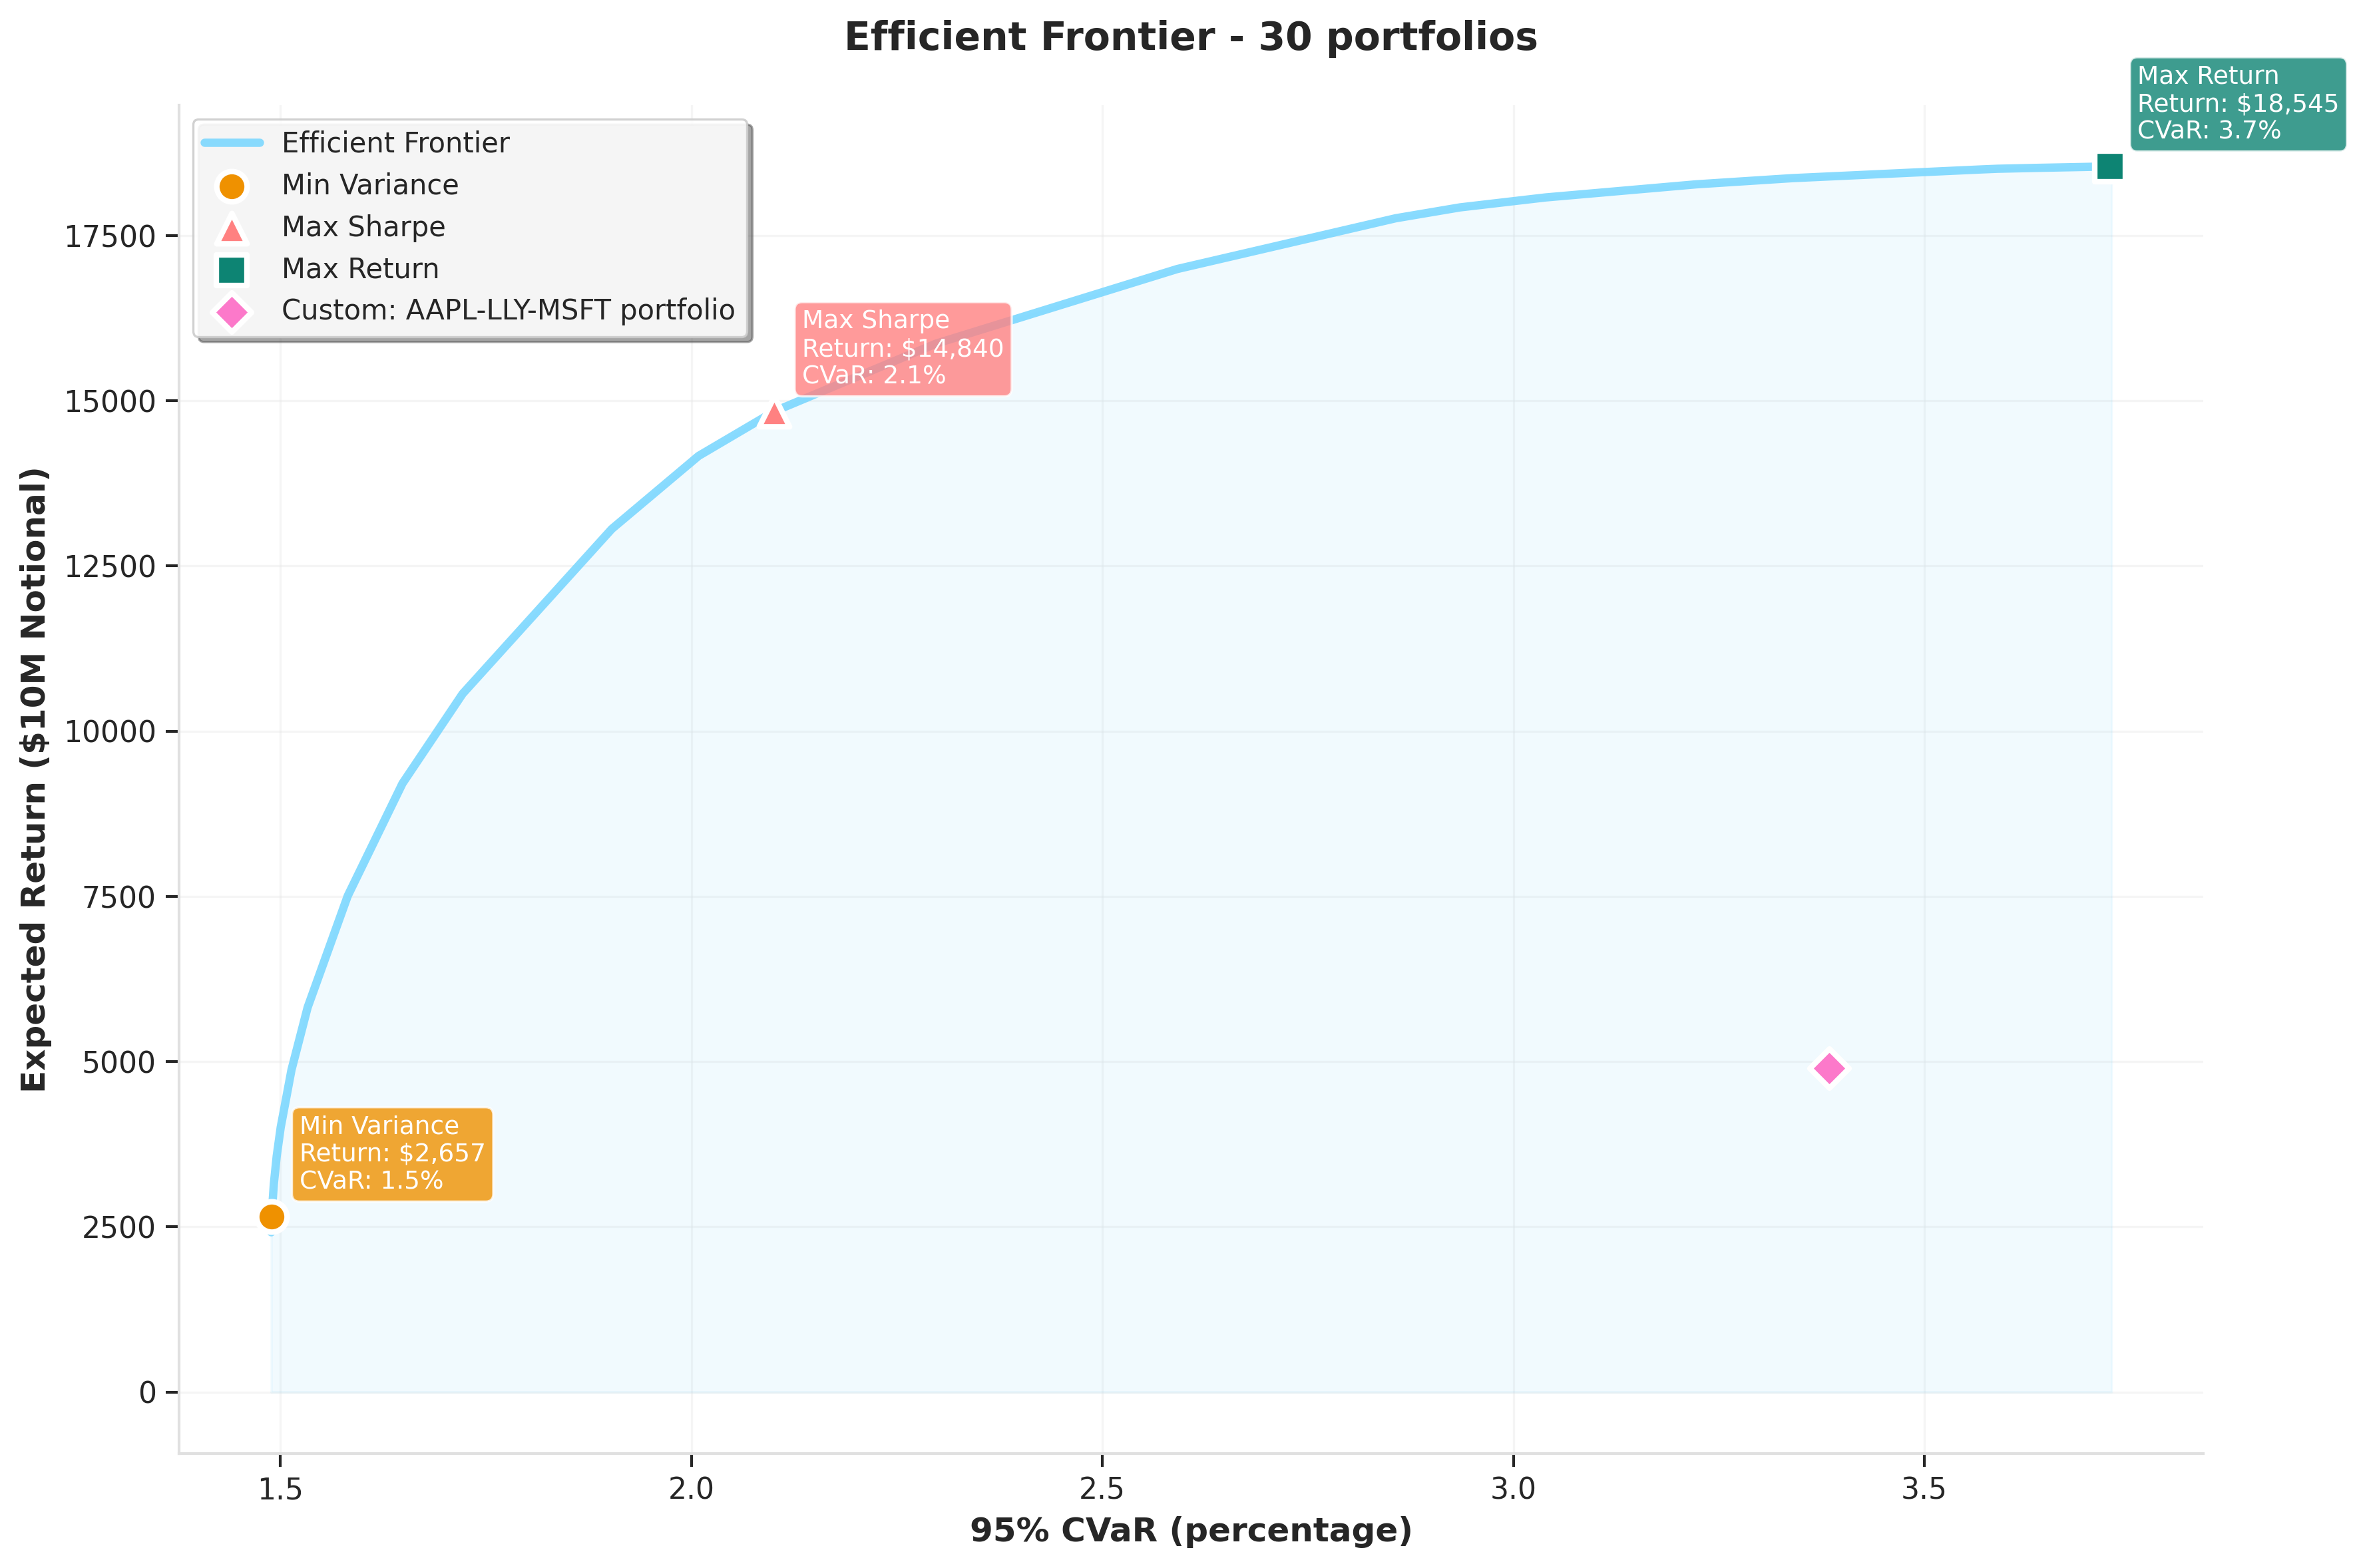

Efficient frontier analysis complete!


In [ ]:
# Define solver settings
ef_solver_settings = {"solver": cp.CUOPT, "verbose": False, 'solver_method': 'PDLP'}

# Create efficient frontier and generate the plot
results_df, fig, ax = cvar_utils.create_efficient_frontier(
    ef_returns_dict,
    ef_cvar_params,
    ef_solver_settings,
    custom_portfolios_dict = ef_custom_portfolios_dict,
    ra_num = ef_risk_aversion_steps,
    min_risk_aversion = ef_min_risk_aversion_exp,
    max_risk_aversion = ef_max_risk_aversion_exp,
    save_path = None,
    show_discretized_portfolios = False, #optional to turn on, but very time consuming
    #discretization_params={
    #    "weight_discretization": 50,
    #    "min_weight": ef_cvar_params.w_min,
    #    "max_weight": ef_cvar_params.w_max
    #},
    print_portfolio_results = False,
    show_plot = True
)

In [6]:
# Display results
results_df

,regime,solver,solve time,return,CVaR,obj,risk_aversion,variance,volatility,sharpe
0,recent,CUOPT,0.272733,0.000242,0.014890,0.148655,10.000000,0.000054,0.007325,0.524004
1,recent,CUOPT,0.194469,0.000246,0.014890,0.108140,7.278954,0.000054,0.007322,0.533812
2,recent,CUOPT,0.187210,0.000250,0.014890,0.078643,5.298317,0.000054,0.007320,0.541378
3,recent,CUOPT,0.188212,0.000257,0.014892,0.057177,3.856620,0.000054,0.007319,0.556612
4,recent,CUOPT,0.180281,0.000266,0.014895,0.041548,2.807216,0.000054,0.007319,0.576315
5,recent,CUOPT,0.186138,0.000283,0.014904,0.030170,2.043360,0.000054,0.007326,0.613517
6,recent,CUOPT,0.192251,0.000316,0.014922,0.021879,1.487352,0.000054,0.007350,0.681690
7,recent,CUOPT,0.201109,0.000357,0.014956,0.015835,1.082637,0.000054,0.007375,0.768576
8,recent,CUOPT,0.211997,0.000401,0.015005,0.011424,0.788046,0.000055,0.007401,0.859538
9,recent,CUOPT,0.212806,0.000487,0.015136,0.008195,0.573615,0.000056,0.007465,1.036552


SPDX-FileCopyrightText: Copyright (c) 2023-2025 NVIDIA CORPORATION & AFFILIATES. All rights reserved. 

SPDX-License-Identifier: Apache-2.0

Licensed under the Apache License, Version 2.0 (the "License");you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.